In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [4]:
data=pd.read_csv("Language Detection.csv")
data.head()

,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English


In [5]:
data["Language"].unique()

array(['English', 'Malayalam', 'Hindi', 'Tamil', 'Portugeese', 'French',
       'Dutch', 'Spanish', 'Greek', 'Russian', 'Danish', 'Italian',
       'Turkish', 'Sweedish', 'Arabic', 'German', 'Kannada'], dtype=object)

In [6]:
x=data["Text"]
y=data["Language"]

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer=CountVectorizer()
x_vector=vectorizer.fit_transform(x)

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_vector,y,test_size=0.2,random_state=42)

In [9]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [10]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.9825918762088974


In [14]:
text = input("Enter a sentence: ")

text_vector = vectorizer.transform([text])

prediction = model.predict(text_vector)[0]

print("\n🔍 Language Detection Result")
print("Detected Language:", prediction)

Enter a sentence:  bonjour



🔍 Language Detection Result
Detected Language: French


In [33]:
probabilities = model.predict_proba(text_vector)

languages = model.classes_

print("\nLanguage Probabilities:")

for lang, prob in zip(languages, probabilities[0]):
    print(lang, ":", round(prob*100,2), "%")


Language Probabilities:
Arabic : 2.78 %
Danish : 2.43 %
Dutch : 2.78 %
English : 3.88 %
French : 3.42 %
German : 2.71 %
Greek : 2.09 %
Hindi : 52.84 %
Italian : 2.97 %
Kannada : 2.38 %
Malayalam : 3.31 %
Portugeese : 3.11 %
Russian : 3.41 %
Spanish : 3.36 %
Sweedish : 3.09 %
Tamil : 2.76 %
Turkish : 2.69 %


In [35]:
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


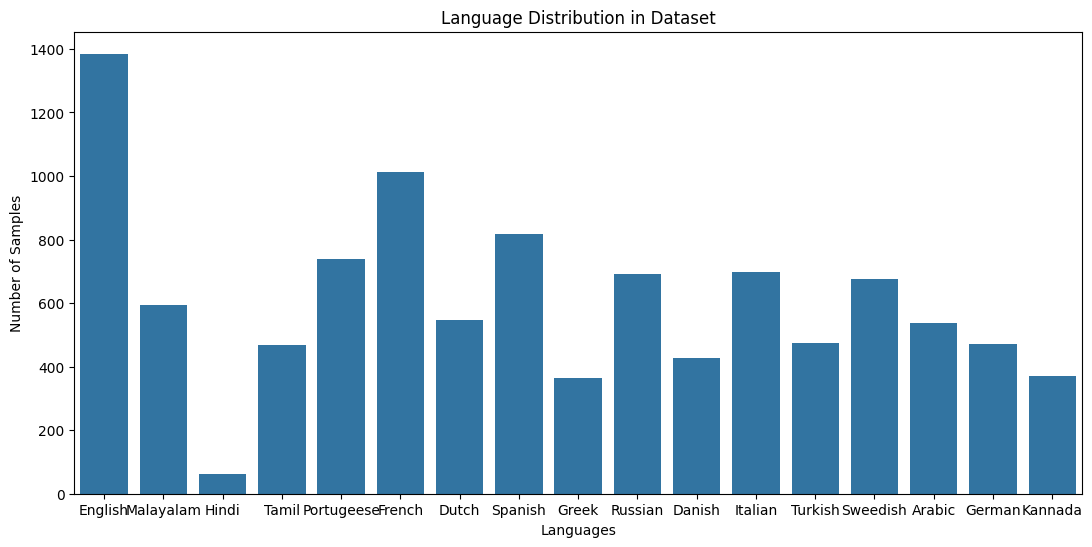

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(13,6))
sns.countplot(x=data["Language"])
plt.title("Language Distribution in Dataset")
plt.xlabel("Languages")
plt.ylabel("Number of Samples")
plt.show()